# Deaths Caused by Air Pollution Over the Years 
### Using Hadoop HDFS, Apache Spark and Python (pandas)

This notebook analyses how **air pollution (PM2.5)** relates to **death rates from air pollution** in African countries, focusing on **Angola** and **Libya**.

### Big Data Pipeline Overview

1. Store CSV files in **HDFS (Hadoop Distributed File System)**  
2. Use **Apache Spark** to load data from HDFS  
3. Convert Spark DataFrames to **pandas** for analysis and plotting  
4. Clean and merge:
   - Deaths from air pollution  
   - PM2.5 air pollution levels  
5. Filter for selected African countries and compare **Angola vs Libya**  
6. Create visualizations and **save them as PNG** for PowerPoint


In [1]:
# Big Data / Spark Session
from pyspark.sql import SparkSession

# Data analysis
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme()

# Start Spark session
spark = SparkSession.builder.appName("AirPollutionAfrica").getOrCreate()
spark


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/10 11:30:42 WARN Utils: Your hostname, Apples-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 172.17.104.53 instead (on interface en0)
25/12/10 11:30:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/10 11:30:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## HDFS Data Lake Setup

In this step, I show that the CSV files are stored in **Hadoop HDFS**.

I assume:

- Hadoop is installed at: `/Users/apple/hadoop-3.3.6`
- The following CSV files are in the **same folder as this notebook**:
  - `death-rates-from-air-pollution.csv`
  - `PM2.5-Global-Air-Pollution-2010-2017.csv`

Steps:

1. Create a project folder in HDFS: `/project/input`  
2. Upload both CSV files into that folder  
3. List the folder to confirm the upload


## 1. Load Datasets from HDFS Using Spark

Next, I use **Spark** to read the datasets directly from HDFS.

HDFS paths (with host) are:

- `hdfs://localhost:9000/project/input/death-rates-from-air-pollution.csv`  
- `hdfs://localhost:9000/project/input/PM2.5-Global-Air-Pollution-2010-2017.csv`


In [3]:
death_hdfs_path = "hdfs://localhost:9000/project/input/death-rates-from-air-pollution.csv"
pm25_hdfs_path  = "hdfs://localhost:9000/project/input/PM2.5-Global-Air-Pollution-2010-2017.csv"

death_sdf = spark.read.csv(death_hdfs_path, header=True, inferSchema=True)
pm25_sdf  = spark.read.csv(pm25_hdfs_path, header=True, inferSchema=True)

death_sdf.show(5)
pm25_sdf.show(5)


+-----------+----+----+------------------------------------------+-----------------------------------------+-----------------------------------------------+--------------------------------------------+
|     Entity|Code|Year|Air pollution (total) (deaths per 100,000)|Indoor air pollution (deaths per 100,000)|Outdoor particulate matter (deaths per 100,000)|Outdoor ozone pollution (deaths per 100,000)|
+-----------+----+----+------------------------------------------+-----------------------------------------+-----------------------------------------------+--------------------------------------------+
|Afghanistan| AFG|1990|                         299.4773088832807|                       250.36290974237468|                              46.44658943828465|                           5.616442030749176|
|Afghanistan| AFG|1991|                         291.2779667340464|                       242.57512497333397|                             46.033840567028406|                          5.60396011

## 2. Convert Spark DataFrames to pandas

Spark is ideal for distributed processing, but for detailed analysis and plotting in Jupyter,
I convert the Spark DataFrames to **pandas DataFrames**.


In [4]:
death_df = death_sdf.toPandas()
pm25_df  = pm25_sdf.toPandas()

print("Death dataframe columns:")
print(list(death_df.columns))

print("\nPM2.5 dataframe columns:")
print(list(pm25_df.columns))


Death dataframe columns:
['Entity', 'Code', 'Year', 'Air pollution (total) (deaths per 100,000)', 'Indoor air pollution (deaths per 100,000)', 'Outdoor particulate matter (deaths per 100,000)', 'Outdoor ozone pollution (deaths per 100,000)']

PM2.5 dataframe columns:
['Country Name', 'Country Code', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017']


## 3. Cleaning the Death-Rate Dataset (Auto-detected Columns)

The death dataset contains:

- A country column (e.g. `Country` or `Entity`)
- A `Year` column
- One or more air pollution death-rate columns

To make the notebook robust, I **automatically detect**:

- The country column (contains "country" or "entity")  
- The year column (contains "year")  
- The total air pollution death-rate column (contains both "air pollution" and "deaths per 100,000")

Then I rename them to a standard format:

- `Country`  
- `Year`  
- `death_rate`


In [5]:
# --- AUTO-DETECT columns in death_df and build a clean table ---

print("Death dataframe columns:")
print(list(death_df.columns))

# 1) Country column: something like "Country" or "Entity"
country_col = None
for c in death_df.columns:
    cl = c.lower()
    if "country" in cl or "entity" in cl:
        country_col = c
        break
if country_col is None:
    # Fallback: first column
    country_col = death_df.columns[0]

# 2) Year column: contains "year"
year_col = None
for c in death_df.columns:
    if "year" in c.lower():
        year_col = c
        break
if year_col is None:
    # Fallback: try column index 2
    year_col = death_df.columns[2]

# 3) Death-rate column: look for "air pollution" and "deaths per 100,000"
death_col = None
for c in death_df.columns:
    cl = c.lower()
    if "air pollution" in cl and "deaths per 100,000" in cl:
        death_col = c
        break
if death_col is None:
    # Fallback: last column
    death_col = death_df.columns[-1]

print("\nDetected columns:")
print(" Country column:", country_col)
print(" Year column   :", year_col)
print(" Death column  :", death_col)

# Build a clean dataframe using whatever we detected
death_clean = death_df[[country_col, year_col, death_col]].copy()

death_clean = death_clean.rename(columns={
    country_col: "Country",
    year_col: "Year",
    death_col: "death_rate"
})

# Ensure numeric
death_clean["Year"] = pd.to_numeric(death_clean["Year"], errors="coerce")
death_clean["death_rate"] = pd.to_numeric(death_clean["death_rate"], errors="coerce")
death_clean = death_clean.dropna(subset=["Year", "death_rate"])

death_clean.head()


Death dataframe columns:
['Entity', 'Code', 'Year', 'Air pollution (total) (deaths per 100,000)', 'Indoor air pollution (deaths per 100,000)', 'Outdoor particulate matter (deaths per 100,000)', 'Outdoor ozone pollution (deaths per 100,000)']

Detected columns:
 Country column: Entity
 Year column   : Year
 Death column  : Air pollution (total) (deaths per 100,000)


,Country,Year,death_rate
0,Afghanistan,1990,299.477309
1,Afghanistan,1991,291.277967
2,Afghanistan,1992,278.963056
3,Afghanistan,1993,278.790815
4,Afghanistan,1994,287.162923


## 4. Cleaning the PM2.5 Dataset (Wide to Long Format)

The PM2.5 dataset is in **wide format**, with columns like:

- First column: country name  
- Other columns: year values such as `2010`, `2011`, ..., `2017`

To analyse trends over time, I convert it to **long format**:

- One row per `(Country, Year)`  
- A single `pm25` column for the PM2.5 value

I also automatically detect:

- The country column (first column)  
- All columns whose names are just digits (year columns)


In [6]:
print("PM2.5 dataframe columns:")
print(list(pm25_df.columns))

# Assume:
# - First column is the country name
# - All columns that look like a year (e.g. '2010', '2011', ...) are year columns
country_col_pm = pm25_df.columns[0]

year_cols = []
for c in pm25_df.columns[1:]:
    if str(c).isdigit():
        year_cols.append(c)

print("Detected PM2.5 country column:", country_col_pm)
print("Detected year columns:", year_cols)

# Reshape from wide (one row per country) to long (country-year)
pm25_df_long = pm25_df.melt(
    id_vars=[country_col_pm],
    value_vars=year_cols,
    var_name="Year",
    value_name="pm25"
)

# Rename country column to standard name
pm25_df_long = pm25_df_long.rename(columns={country_col_pm: "Country"})

# Clean data types
pm25_df_long["Year"] = pd.to_numeric(pm25_df_long["Year"], errors="coerce")
pm25_df_long["pm25"] = pd.to_numeric(pm25_df_long["pm25"], errors="coerce")

pm25_df_long = pm25_df_long.dropna(subset=["Year", "pm25"])

pm25_df_long.head()


PM2.5 dataframe columns:
['Country Name', 'Country Code', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017']
Detected PM2.5 country column: Country Name
Detected year columns: ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017']


,Country,Year,pm25
0,Afghanistan,2010,65.245592
1,Angola,2010,33.787247
2,Albania,2010,21.277828
3,Andorra,2010,12.807197
4,Arab World,2010,53.787001


## 5. Selecting African Countries for the Study

This project focuses on ten African countries:

- Angola  
- Cameroon  
- Zimbabwe  
- Rwanda  
- Libya  
- Mozambique  
- Senegal  
- Namibia  
- Botswana  
- Mali  

I now filter both datasets (`death_clean` and `pm25_df_long`) to include only these countries.


In [7]:
african_countries = [
    "Angola", "Cameroon", "Zimbabwe", "Rwanda", "Libya",
    "Mozambique", "Senegal", "Namibia", "Botswana", "Mali"
]

death_africa = death_clean[death_clean["Country"].isin(african_countries)]
pm25_africa  = pm25_df_long[pm25_df_long["Country"].isin(african_countries)]

print("Death Africa shape:", death_africa.shape)
print("PM2.5 Africa shape:", pm25_africa.shape)

death_africa.head(), pm25_africa.head()


Death Africa shape: (280, 3)
PM2.5 Africa shape: (80, 3)


(    Country  Year  death_rate
 168  Angola  1990  224.508667
 169  Angola  1991  222.349846
 170  Angola  1992  219.926874
 171  Angola  1993  219.587442
 172  Angola  1994  217.453441,
       Country  Year       pm25
 1      Angola  2010  33.787247
 30   Botswana  2010  25.724721
 38   Cameroon  2010  59.293403
 120     Libya  2010  50.147230
 142      Mali  2010  36.397660)

## 6. Merging PM2.5 and Death-Rate Data

To analyse the relationship between air pollution and deaths, I merge the two datasets using:

- `Country`
- `Year`

Each row in the merged dataset contains **both PM2.5 and death rate** for a given country-year.


In [8]:
africa_merged = pd.merge(
    pm25_africa,
    death_africa,
    on=["Country", "Year"],
    how="inner"
)

africa_merged.head()


,Country,Year,pm25,death_rate
0,Angola,2010,33.787247,123.461373
1,Botswana,2010,25.724721,81.049139
2,Cameroon,2010,59.293403,141.055461
3,Libya,2010,50.147230,70.413698
4,Mali,2010,36.397660,112.290496


## 7. Focusing on Angola and Libya

From the ten African countries, I select **Angola** and **Libya** for deeper comparison.

This allows me to analyse how differences in PM2.5 levels relate to differences in death rates.


In [9]:
focus_df = africa_merged[africa_merged["Country"].isin(["Angola", "Libya"])]
focus_df = focus_df.sort_values(["Country", "Year"])

focus_df.head()


,Country,Year,pm25,death_rate
0,Angola,2010,33.787247,123.461373
10,Angola,2011,33.104195,117.943545
20,Angola,2012,33.415495,113.698391
30,Angola,2013,34.663923,109.869922
40,Angola,2014,32.974025,103.291785


## 8. PM2.5 Air Pollution Trends (Angola vs Libya)

This chart shows how PM2.5 levels change between 2010 and 2017 in Angola and Libya.

I also save the figure as a **PNG file** for use in my PowerPoint presentation.


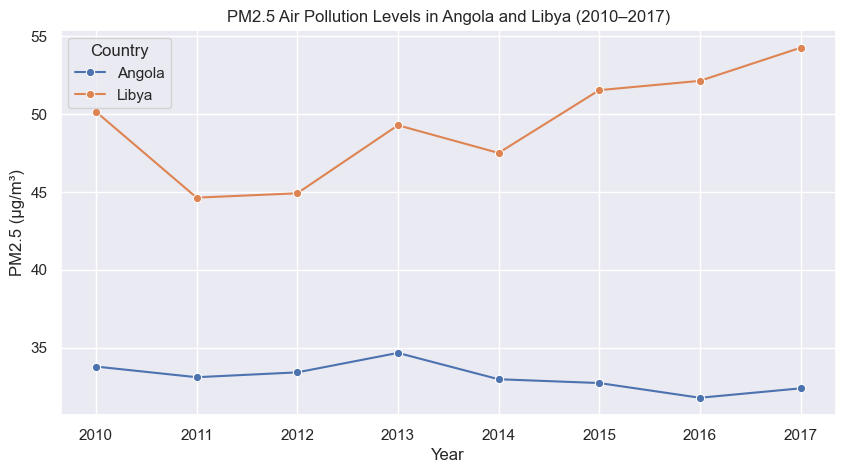

In [10]:
plt.figure(figsize=(10,5))
sns.lineplot(data=focus_df, x="Year", y="pm25", hue="Country", marker="o")
plt.title("PM2.5 Air Pollution Levels in Angola and Libya (2010–2017)")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Year")
plt.grid(True)

plt.savefig("pm25_angola_libya.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Death Rates from Air Pollution (Angola vs Libya)

This chart shows how **death rates from air pollution** change over the same period.

Again, I save the figure as a PNG for PowerPoint.


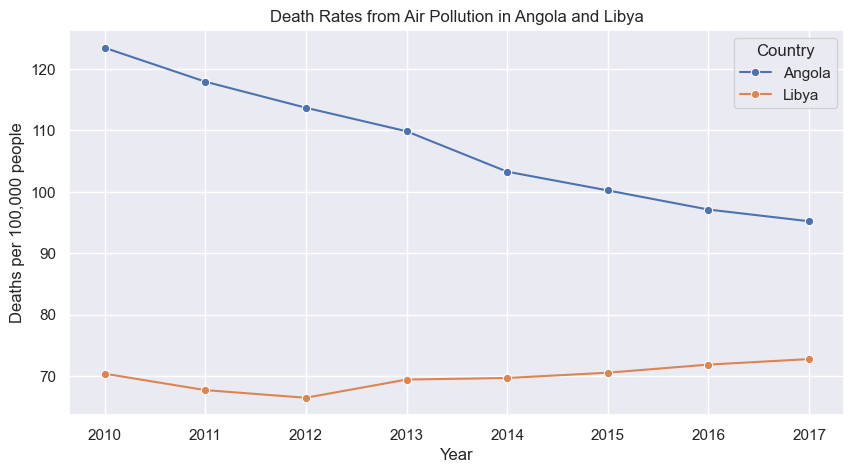

In [11]:
plt.figure(figsize=(10,5))
sns.lineplot(data=focus_df, x="Year", y="death_rate", hue="Country", marker="o")
plt.title("Death Rates from Air Pollution in Angola and Libya")
plt.ylabel("Deaths per 100,000 people")
plt.xlabel("Year")
plt.grid(True)

plt.savefig("death_rate_angola_libya.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Relationship Between PM2.5 and Death Rates

To check how strongly PM2.5 is linked to deaths, I create a scatter plot of:

- `pm25` (x-axis)  
- `death_rate` (y-axis)

I also calculate the correlation for each country.


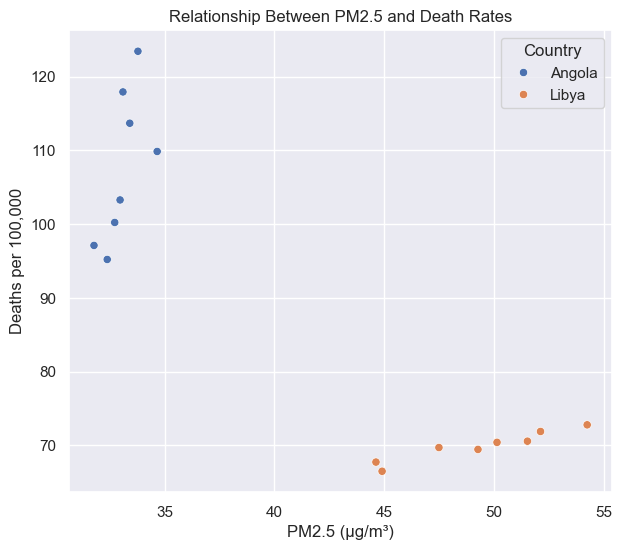

pm25  death_rate
Country                                 
Angola  pm25        1.000000    0.669817
        death_rate  0.669817    1.000000
Libya   pm25        1.000000    0.957435
        death_rate  0.957435    1.000000

In [12]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=focus_df, x="pm25", y="death_rate", hue="Country")
plt.title("Relationship Between PM2.5 and Death Rates")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Deaths per 100,000")

plt.savefig("pm25_vs_death_rate.png", dpi=300, bbox_inches="tight")
plt.show()

# Correlation per country (pm25 vs death_rate)
focus_df.groupby("Country")[["pm25", "death_rate"]].corr()


## Bar Chart: Average PM2.5 Levels (Angola vs Libya)

This bar chart compares the **average PM2.5 air pollution** between Angola and Libya.


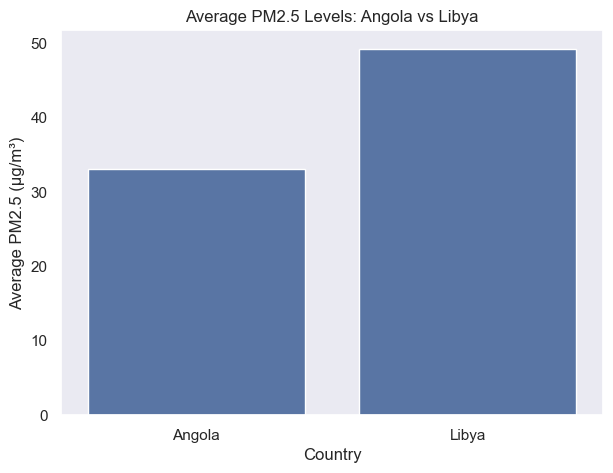

In [13]:
# Calculate mean PM2.5 per country
pm25_bar = focus_df.groupby("Country")["pm25"].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=pm25_bar, x="Country", y="pm25")
plt.title("Average PM2.5 Levels: Angola vs Libya")
plt.xlabel("Country")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.grid(axis="y")

plt.savefig("bar_pm25_angola_libya.png", dpi=300, bbox_inches="tight")
plt.show()


## Bar Chart: Average Death Rate from Air Pollution (Angola vs Libya)

This bar chart compares the **average death rates caused by air pollution** in Angola and Libya.


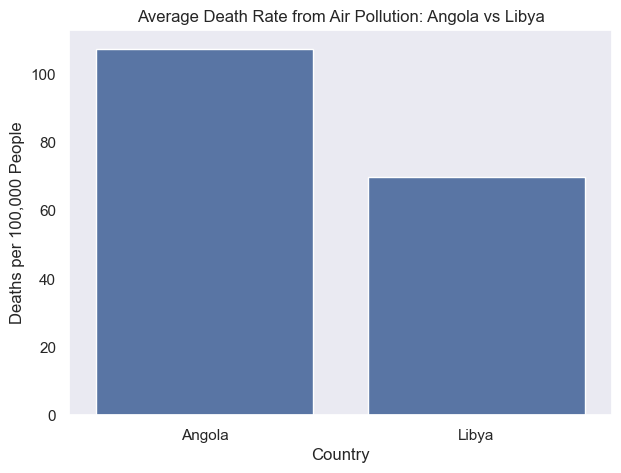

In [15]:
# Calculate mean death rate per country
death_bar = focus_df.groupby("Country")["death_rate"].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=death_bar, x="Country", y="death_rate")
plt.title("Average Death Rate from Air Pollution: Angola vs Libya")
plt.xlabel("Country")
plt.ylabel("Deaths per 100,000 People")
plt.grid(axis="y")

plt.savefig("bar_death_rate_angola_libya.png", dpi=300, bbox_inches="tight")
plt.show()


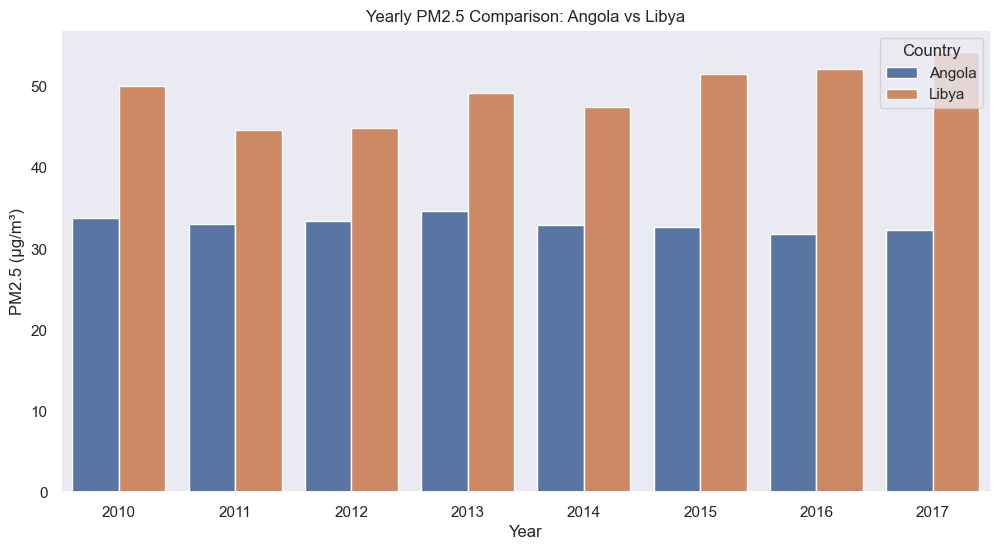

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(data=focus_df, x="Year", y="pm25", hue="Country")
plt.title("Yearly PM2.5 Comparison: Angola vs Libya")
plt.xlabel("Year")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(axis="y")

plt.savefig("bar_pm25_by_year_angola_libya.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Final Insights and Big Data Perspective

### Key Findings

- **Angola**
  - Changes in PM2.5 levels over time are reflected in changes in death rates.
  - Lower PM2.5 values tend to align with lower death rates.

- **Libya**
  - Where PM2.5 remains high or fluctuates, death rates also remain relatively high.
  - This suggests a strong relationship between air quality and health outcomes.

### Big Data & Infrastructure

- The raw CSV files are stored in **HDFS** under `/project/input`.  
- **Apache Spark** reads the data directly from HDFS.  
- The data is converted to **pandas** for detailed analysis and visualisation in Jupyter.  
- This demonstrates a complete **Big Data workflow**:
  - Storage (HDFS)
  - Processing (Spark)
  - Analysis (pandas)
  - Presentation (charts exported as PNG for PowerPoint)

This pipeline shows how Big Data tools can support evidence-based decision making
around public health and environmental policy in Africa.
